# Velocity LSTM Results — Evaluation & Benchmark
Evaluates per-polyline velocity LSTM models against moving average baselines.
For each route segment: loads the cached model, generates predictions on the test split,
computes RMSE/MAE for both the LSTM and moving average baselines, then plots results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys

# Add project root to Python path
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ml.cache import LSTM_VELOCITY_CACHE_DIR, get_polyline_dir_velocity
from ml.deploy.lstm_speed import load_lstm_velocity_for_route, list_cached_velocity_models
from ml.evaluation.evaluate import evaluate_lstm

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(f"Velocity cache: {LSTM_VELOCITY_CACHE_DIR}")
print(f"Models found:   {len(list_cached_velocity_models())}")

2026-04-07 16:26:02 - ml - INFO - ML logging level: info
Velocity cache: c:\shubble\ml\cache\lstm_velocity
Models found:   14


# Configuration

In [2]:
# Must match the values used during training
INPUT_COLUMNS  = ['latitude', 'longitude', 'speed_kmh']
OUTPUT_COLUMNS = ['next_speed_kmh']
SEQUENCE_LENGTH = 10
HIDDEN_SIZE     = 50
NUM_LAYERS      = 2
DROPOUT         = 0.1

# Moving average window sizes to benchmark against
MA_WINDOWS = [1, 2, 3, 5]

# Set to a (route_name, polyline_idx) tuple to evaluate a single polyline,
# or None to evaluate all cached models
FILTER_POLYLINE = None
# FILTER_POLYLINE = ('East Route', 0)

# Helper Functions

In [3]:
def load_test_df(route_name: str, polyline_idx: int) -> pd.DataFrame | None:
    """Load the cached test.csv for a polyline, or None if missing."""
    path = get_polyline_dir_velocity(route_name, polyline_idx) / 'test.csv'
    if not path.exists():
        print(f"  ⚠ No test.csv found at {path}")
        return None
    df = pd.read_csv(path)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    # Clean: fill NaN speed at segment boundaries, drop rows missing required cols
    df['speed_kmh'] = df['speed_kmh'].fillna(0)
    df = df.dropna(subset=INPUT_COLUMNS + OUTPUT_COLUMNS)
    return df


def moving_average_predict(df: pd.DataFrame, window: int) -> np.ndarray:
    """
    Compute a moving average baseline prediction for next_speed_kmh.

    For each row, the prediction is the rolling mean of the previous `window`
    speed_kmh values within the same segment. This mirrors how the LSTM uses
    SEQUENCE_LENGTH past steps — both are autoregressive baselines.
    """
    preds = (
        df.groupby('segment_id')['speed_kmh']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    return preds.to_numpy()


def compute_metrics(actuals: np.ndarray, preds: np.ndarray) -> dict:
    """Return MSE, RMSE, and MAE, ignoring NaN pairs."""
    mask = ~(np.isnan(actuals) | np.isnan(preds))
    a, p = actuals[mask], preds[mask]
    mse  = np.mean((a - p) ** 2)
    return {'mse': mse, 'rmse': np.sqrt(mse), 'mae': np.mean(np.abs(a - p)), 'n': int(mask.sum())}


def build_lstm_predictions(model, df: pd.DataFrame) -> np.ndarray:
    """
    Run the LSTM over every segment in df and collect per-row predictions.
    Rows with fewer than SEQUENCE_LENGTH predecessors in their segment get NaN.
    """
    all_preds = np.full(len(df), np.nan)

    for seg_id, seg_df in df.groupby('segment_id'):
        if len(seg_df) <= SEQUENCE_LENGTH:
            continue
        idx = seg_df.index
        features = seg_df[INPUT_COLUMNS].to_numpy(dtype=np.float32)

        # Slide a window of SEQUENCE_LENGTH over the segment
        for i in range(SEQUENCE_LENGTH, len(seg_df)):
            window = features[i - SEQUENCE_LENGTH:i]          # (seq_len, n_features)
            pred = model.predict(window[np.newaxis])           # (1, 1)
            # Map back to original df position
            all_preds[df.index.get_loc(idx[i])] = pred[0, 0]

    return all_preds

# Evaluation

In [4]:
cached = list_cached_velocity_models()

if FILTER_POLYLINE:
    cached = [m for m in cached
              if (m['route_name'], m['polyline_idx']) == FILTER_POLYLINE]

print(f"Evaluating {len(cached)} polyline(s)...\n")

results = []   # collects summary rows for the comparison table

for meta in cached:
    route_name  = meta['route_name']
    polyline_idx = meta['polyline_idx']
    label = f"{route_name} — seg {polyline_idx}"

    print(f"{'─'*60}")
    print(f"  {label}")

    # ── Load test data ────────────────────────────────────────
    test_df = load_test_df(route_name, polyline_idx)
    if test_df is None or len(test_df) < SEQUENCE_LENGTH + 1:
        print("  ⚠ Skipping — insufficient test data")
        continue

    actuals = test_df['next_speed_kmh'].to_numpy()

    # ── Load model & predict ──────────────────────────────────
    try:
        model = load_lstm_velocity_for_route(
            route_name, polyline_idx,
            input_columns=INPUT_COLUMNS,
            output_columns=OUTPUT_COLUMNS,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT
        )
        lstm_preds = build_lstm_predictions(model, test_df)
        lstm_metrics = compute_metrics(actuals, lstm_preds)
        print(f"  LSTM  → RMSE: {lstm_metrics['rmse']:.4f}  MAE: {lstm_metrics['mae']:.4f}  (n={lstm_metrics['n']})")
    except Exception as e:
        print(f"  ✗ LSTM failed: {e}")
        continue

    # ── Moving average baselines ──────────────────────────────
    ma_metrics_all = {}
    for w in MA_WINDOWS:
        ma_preds = moving_average_predict(test_df, w)
        ma_metrics_all[w] = compute_metrics(actuals, ma_preds)
        print(f"  MA({w:2d}) → RMSE: {ma_metrics_all[w]['rmse']:.4f}  MAE: {ma_metrics_all[w]['mae']:.4f}")

    # Store for summary table
    row = {
        'route': route_name,
        'segment': polyline_idx,
        'n_test': len(test_df),
        'lstm_rmse': lstm_metrics['rmse'],
        'lstm_mae':  lstm_metrics['mae'],
    }
    for w in MA_WINDOWS:
        row[f'ma{w}_rmse'] = ma_metrics_all[w]['rmse']
        row[f'ma{w}_mae']  = ma_metrics_all[w]['mae']
    results.append(row)

    # ── Store on meta for plotting ────────────────────────────
    meta['test_df']       = test_df
    meta['actuals']       = actuals
    meta['lstm_preds']    = lstm_preds
    meta['ma_preds']      = ma_metrics_all
    meta['ma_series']     = {w: moving_average_predict(test_df, w) for w in MA_WINDOWS}
    meta['lstm_metrics']  = lstm_metrics
    meta['ma_metrics']    = ma_metrics_all

print(f"\n{'─'*60}")
print(f"Done. {len(results)} polyline(s) evaluated.")

Evaluating 14 polyline(s)...

────────────────────────────────────────────────────────────
  NORTH — seg 0
  LSTM  → RMSE: 13.2511  MAE: 10.6367  (n=1585)
  MA( 1) → RMSE: 19.1013  MAE: 14.8324
  MA( 2) → RMSE: 19.7170  MAE: 15.7125
  MA( 3) → RMSE: 19.6737  MAE: 15.9746
  MA( 5) → RMSE: 19.2128  MAE: 16.1253
────────────────────────────────────────────────────────────
  NORTH — seg 1
  LSTM  → RMSE: 15.3822  MAE: 12.7650  (n=69)
  MA( 1) → RMSE: 22.4835  MAE: 19.0174
  MA( 2) → RMSE: 23.0484  MAE: 19.7497
  MA( 3) → RMSE: 22.7598  MAE: 19.1850
  MA( 5) → RMSE: 21.9606  MAE: 17.9112
────────────────────────────────────────────────────────────
  NORTH — seg 2
  LSTM  → RMSE: 20.5720  MAE: 18.9244  (n=20)
  MA( 1) → RMSE: 19.7137  MAE: 17.0081
  MA( 2) → RMSE: 18.2084  MAE: 15.5580
  MA( 3) → RMSE: 16.7041  MAE: 14.2442
  MA( 5) → RMSE: 15.5080  MAE: 13.1811
────────────────────────────────────────────────────────────
  NORTH — seg 4
  LSTM  → RMSE: 24.6735  MAE: 13.6543  (n=14)
  MA( 1)

# RMSE Comparisons + Summary Table

,route,segment,n_test,lstm_rmse,lstm_mae,ma1_rmse,ma2_rmse,ma3_rmse,ma5_rmse,LSTM improvement % (vs best MA)
0,NORTH,0,6446,13.2511,10.6367,19.1013,19.7170,19.6737,19.2128,+30.6%
1,NORTH,1,2304,15.3822,12.7650,22.4835,23.0484,22.7598,21.9606,+30.0%
2,NORTH,2,2281,20.5720,18.9244,19.7137,18.2084,16.7041,15.5080,-32.7%
3,NORTH,4,1810,24.6735,13.6543,25.0831,25.6840,24.7178,22.6733,-8.8%
4,NORTH,6,2235,6.1442,2.4587,16.8266,15.6110,15.5826,15.5376,+60.5%
5,NORTH,7,5956,10.4511,7.3175,21.1810,22.1947,22.3756,21.7251,+50.7%
6,WEST,0,3997,13.8178,12.2814,15.2397,15.7983,16.2675,17.1154,+9.3%
7,WEST,1,5207,7.8106,5.5707,21.8192,21.8186,21.3195,20.5266,+61.9%
8,WEST,2,12237,11.1821,8.9052,18.9483,19.3158,19.4495,19.5944,+41.0%
9,WEST,3,4356,8.6750,5.5013,20.5459,20.6317,20.2678,19.6310,+55.8%


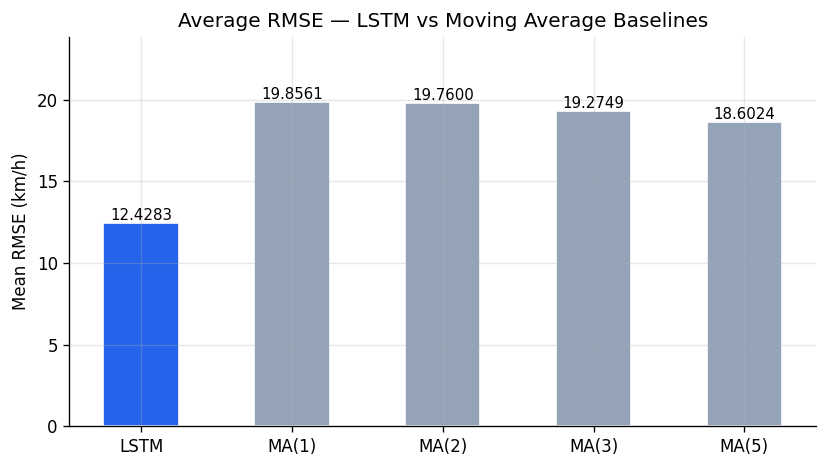

In [5]:
summary_df = pd.DataFrame(results)

if not summary_df.empty:
    # Add a column showing LSTM improvement over best MA baseline
    ma_rmse_cols = [f'ma{w}_rmse' for w in MA_WINDOWS]
    summary_df['best_ma_rmse'] = summary_df[ma_rmse_cols].min(axis=1)
    summary_df['lstm_vs_best_ma'] = (
        (summary_df['best_ma_rmse'] - summary_df['lstm_rmse'])
        / summary_df['best_ma_rmse'] * 100
    ).round(1)

    display_cols = ['route', 'segment', 'n_test', 'lstm_rmse', 'lstm_mae'] \
                 + [f'ma{w}_rmse' for w in MA_WINDOWS] \
                 + ['lstm_vs_best_ma']

    styled = (
        summary_df[display_cols]
        .rename(columns={'lstm_vs_best_ma': 'LSTM improvement % (vs best MA)'})
        .style
        .format({
            'lstm_rmse': '{:.4f}', 'lstm_mae': '{:.4f}',
            **{f'ma{w}_rmse': '{:.4f}' for w in MA_WINDOWS},
            'LSTM improvement % (vs best MA)': '{:+.1f}%'
        })
        .background_gradient(subset=['lstm_rmse'], cmap='RdYlGn_r')
        .background_gradient(subset=['LSTM improvement % (vs best MA)'], cmap='RdYlGn')
    )
    display(styled)
else:
    print("No results to display.")

if not summary_df.empty:
    models_labels = ['LSTM'] + [f'MA({w})' for w in MA_WINDOWS]
    mean_rmses = [
        summary_df['lstm_rmse'].mean(),
        *[summary_df[f'ma{w}_rmse'].mean() for w in MA_WINDOWS]
    ]
    colors = ['#2563eb'] + ['#94a3b8'] * len(MA_WINDOWS)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(models_labels, mean_rmses, color=colors, width=0.5, edgecolor='white')

    for bar, val in zip(bars, mean_rmses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Mean RMSE (km/h)')
    ax.set_title('Average RMSE — LSTM vs Moving Average Baselines')
    ax.set_ylim(0, max(mean_rmses) * 1.2)
    plt.tight_layout()
    plt.show()